# EfficientNet-B0 Experiment 09 — Aug + L1 + Dropout + Patient Metadata Fusion + TTA

## Objective
This notebook combines Experiments 05 and 06 into a single self-contained run. Experiment 05 trained an `EfficientNetB0WithMetadata` model (last 6 blocks unfrozen, Dropout=0.5, L1=1e-3, patient metadata dim=17) and achieved Test F2 **0.6875**. Experiment 06 applied 8× deterministic TTA to the Iter 05 checkpoint at inference and pushed Test F2 to **0.6952**, beating the 0.6879 benchmark. This notebook replicates that full pipeline — train then evaluate with TTA — in one place.

## Architecture

| Component | Config |
|---|---|
| Variant | EfficientNet-B0 |
| Unfrozen blocks | last 6 of `features` |
| Weight decay | 1e-3 |
| L1 lambda | 1e-3 |
| Dropout | 0.5 |
| Patient metadata | age + sex + localization (dim=17) |
| LR — backbone | 1e-4 |
| LR — head | 1e-3 |
| Scheduler | CosineAnnealingLR |
| Epochs | 30 |
| TTA at inference | Yes (8× deterministic geometric) |

## Hypothesis
Applying deterministic 8× TTA (identity, H-flip, V-flip, HV-flip, rotate 90/180/270/45) to the best-AUC checkpoint averages out prediction variance and raises recall, pushing Test F2 above the 0.6879 benchmark without any additional training.

## Import libraries, set seed, and choose device

In [1]:
import sys
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import transforms
from sklearn.metrics import fbeta_score

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

from src.data.dataset import HAM10000DatasetWithMetadata
from src.data.transform import get_augmented_train_transforms, get_eval_transforms
from src.models.efficientnet import EfficientNetB0WithMetadata
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model

import pandas as pd

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


## Load and split data

In [2]:
METADATA_PATH      = str(ROOT / 'data_new/raw/HAM10000_metadata')
TEST_METADATA_PATH = str(ROOT / 'data_new/raw/ISIC2018_Task3_Test_GroundTruth.csv')

train_dataset = HAM10000DatasetWithMetadata(
    csv_path=str(ROOT / 'data_new/splits/train.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    metadata_path=METADATA_PATH,
    transform=get_augmented_train_transforms(image_size=224),
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
)

val_dataset = HAM10000DatasetWithMetadata(
    csv_path=str(ROOT / 'data_new/splits/val.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    metadata_path=METADATA_PATH,
    transform=get_eval_transforms(image_size=224),
)
val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    persistent_workers=True,
)

test_dataset = HAM10000DatasetWithMetadata(
    csv_path=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/test'),
    metadata_path=TEST_METADATA_PATH,
    transform=get_eval_transforms(image_size=224),
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    persistent_workers=True,
)

train_df     = pd.read_csv(ROOT / 'data_new/splits/train.csv')
num_melanoma = (train_df['label'] == 1).sum()
num_nevus    = (train_df['label'] == 0).sum()
pos_weight   = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)
print('Positive weight:', pos_weight)
print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')
print(f'Metadata dim: {len(train_dataset[0][1])}')

Positive weight: tensor([8.1117], device='cuda:0')
Train: 7991 | Val: 2024 | Test: 1511
Metadata dim: 17


## Model Definition

In [3]:
METADATA_DIM      = 17   # age(1) + sex(1) + localization one-hot(15)
DROPOUT           = 0.5
UNFREEZE_N_BLOCKS = 6    # unfreeze last 6 of model.features (blocks 3-8)

model = EfficientNetB0WithMetadata(
    metadata_dim=METADATA_DIM,
    num_classes=1,
    freeze_backbone=True,
    dropout=DROPOUT,
).to(device)

# Unfreeze last N blocks of EfficientNet features
# model.features: [0]=stem, [1-7]=MBConv blocks, [8]=head conv
for block in list(model.features)[-UNFREEZE_N_BLOCKS:]:
    for param in block.parameters():
        param.requires_grad = True

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

unfrozen_params = [p for block in list(model.features)[-UNFREEZE_N_BLOCKS:]
                   for p in block.parameters()]
optimizer = optim.AdamW([
    {'params': unfrozen_params,                  'lr': 1e-4},
    {'params': model.meta_encoder.parameters(),  'lr': 1e-3},
    {'params': model.head.parameters(),          'lr': 1e-3},
], weight_decay=1e-3)

num_epochs = 30
scheduler  = CosineAnnealingLR(optimizer, T_max=num_epochs)

L1_LAMBDA = 1e-3
L2_LAMBDA = 0.0

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')
print(f'L1 lambda: {L1_LAMBDA} | L2 lambda: {L2_LAMBDA} | Dropout: {DROPOUT}')

Trainable params: 3,990,347 / 4,009,437
L1 lambda: 0.001 | L2 lambda: 0.0 | Dropout: 0.5


## Training Loop

In [4]:
best_val_auc = 0.0
best_epoch   = 0
train_history, val_history = [], []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(
        model, train_loader, criterion, optimizer, device,
        l1_lambda=L1_LAMBDA, l2_lambda=L2_LAMBDA, use_metadata=True,
    )
    val_metrics = validate_one_epoch(
        model, val_loader, criterion, device, use_metadata=True,
    )

    scheduler.step()

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train | Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f}, AUC: {train_metrics['auc']:.4f}")
    print(f"  Val   | Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}, AUC: {val_metrics['auc']:.4f}")

    if val_metrics['auc'] > best_val_auc:
        best_val_auc = val_metrics['auc']
        best_epoch   = epoch + 1
        torch.save(model.state_dict(), ROOT / 'models/efficientnet_b0_l1_metadata_best.pth')
        print(f'  -> Saved best model (val AUC: {best_val_auc:.4f})')

print(f'Best checkpoint: epoch {best_epoch} | Val AUC: {best_val_auc:.4f}')

Epoch [1/30]
  Train | Loss: 0.9371, Bal Acc: 0.7330, Recall: 0.8107, F2: 0.5329, AUC: 0.8052
  Val   | Loss: 0.8021, Bal Acc: 0.7831, Recall: 0.8856, F2: 0.6061, AUC: 0.8789
  -> Saved best model (val AUC: 0.8789)


Epoch [2/30]
  Train | Loss: 0.8158, Bal Acc: 0.7734, Recall: 0.8381, F2: 0.5819, AUC: 0.8587
  Val   | Loss: 0.7945, Bal Acc: 0.7763, Recall: 0.9280, F2: 0.5971, AUC: 0.8868
  -> Saved best model (val AUC: 0.8868)


Epoch [3/30]
  Train | Loss: 0.7465, Bal Acc: 0.8037, Recall: 0.8461, F2: 0.6237, AUC: 0.8850
  Val   | Loss: 0.7668, Bal Acc: 0.7835, Recall: 0.8305, F2: 0.6083, AUC: 0.8838


Epoch [4/30]
  Train | Loss: 0.7243, Bal Acc: 0.8097, Recall: 0.8632, F2: 0.6309, AUC: 0.8910
  Val   | Loss: 0.7396, Bal Acc: 0.7964, Recall: 0.8602, F2: 0.6246, AUC: 0.8929
  -> Saved best model (val AUC: 0.8929)


Epoch [5/30]
  Train | Loss: 0.7180, Bal Acc: 0.8162, Recall: 0.8643, F2: 0.6406, AUC: 0.8955
  Val   | Loss: 0.7531, Bal Acc: 0.7893, Recall: 0.8347, F2: 0.6160, AUC: 0.8917


...

Epoch [26/30]
  Train | Loss: 0.4686, Bal Acc: 0.8850, Recall: 0.9122, F2: 0.7520, AUC: 0.9564
  Val   | Loss: 0.8096, Bal Acc: 0.8231, Recall: 0.7754, F2: 0.6738, AUC: 0.9114


Epoch [27/30]
  Train | Loss: 0.4641, Bal Acc: 0.8859, Recall: 0.9122, F2: 0.7537, AUC: 0.9572
  Val   | Loss: 0.8237, Bal Acc: 0.8166, Recall: 0.7669, F2: 0.6635, AUC: 0.9106


Epoch [28/30]
  Train | Loss: 0.4480, Bal Acc: 0.8930, Recall: 0.9202, F2: 0.7658, AUC: 0.9601
  Val   | Loss: 0.8592, Bal Acc: 0.8198, Recall: 0.7627, F2: 0.6696, AUC: 0.9101


Epoch [29/30]
  Train | Loss: 0.4721, Bal Acc: 0.8803, Recall: 0.8951, F2: 0.7476, AUC: 0.9553
  Val   | Loss: 0.8423, Bal Acc: 0.8196, Recall: 0.7712, F2: 0.6681, AUC: 0.9084


Epoch [30/30]
  Train | Loss: 0.4515, Bal Acc: 0.8961, Recall: 0.9247, F2: 0.7706, AUC: 0.9589
  Val   | Loss: 0.8261, Bal Acc: 0.8156, Recall: 0.7627, F2: 0.6623, AUC: 0.9107
Best checkpoint: epoch 21 | Val AUC: 0.9167


## Plot Train and Validation Curves

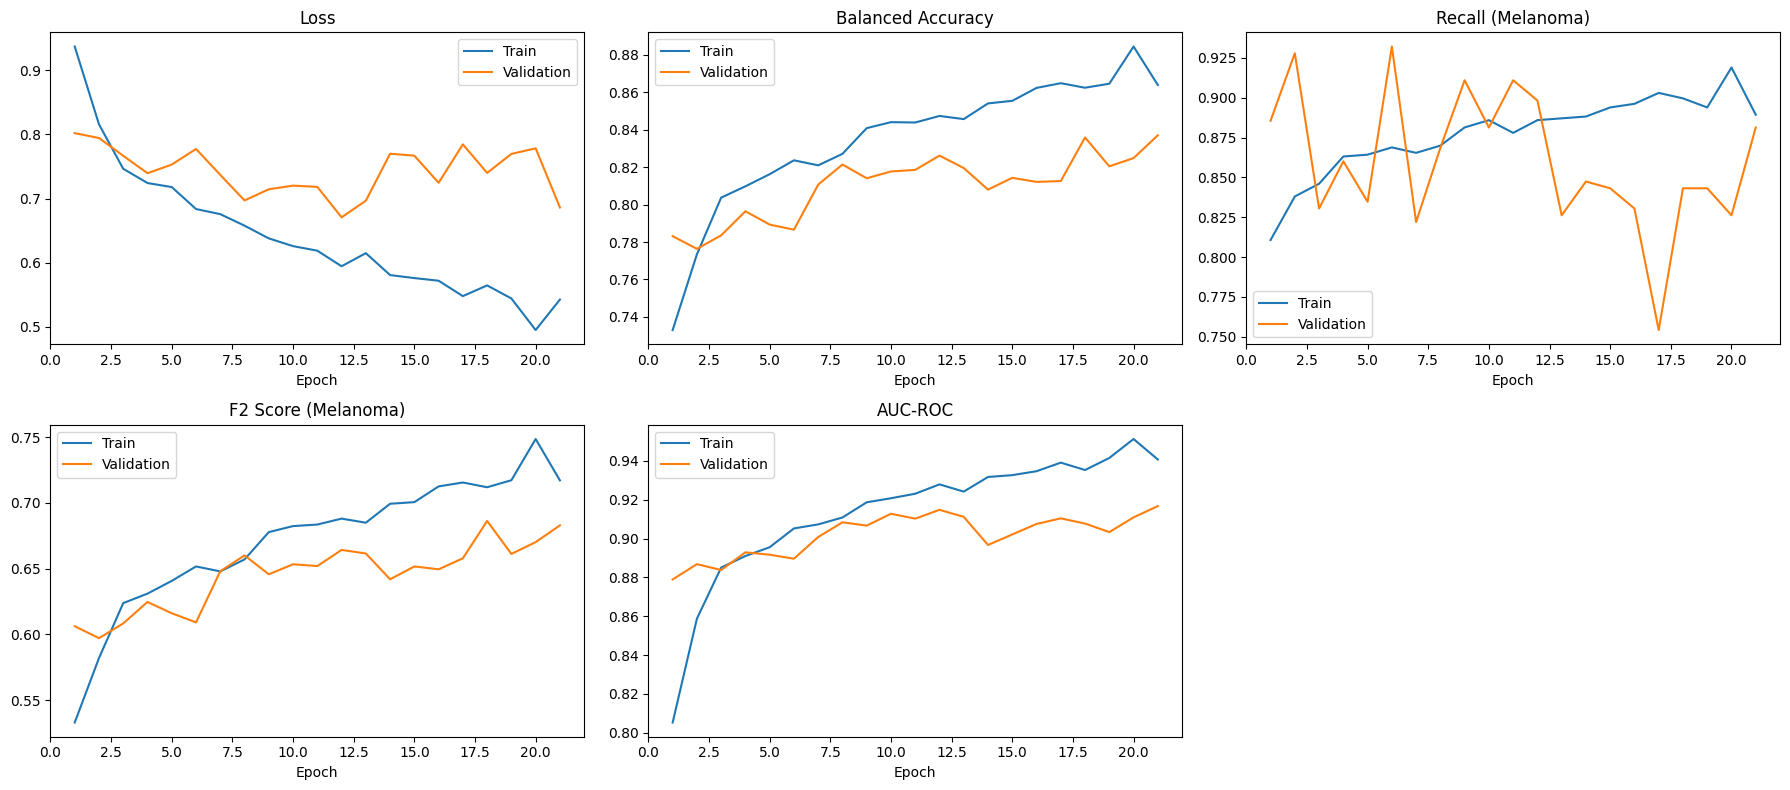

In [5]:
plot_training_curves(train_history, val_history, best_epoch=best_epoch)

## Threshold Tuning (Best Val F2)

In [6]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

model.load_state_dict(torch.load(str(ROOT / 'models/efficientnet_b0_l1_metadata_best.pth'), map_location=device))
model.eval()

val_dataset_raw = HAM10000DatasetWithMetadata(
    csv_path=str(ROOT / 'data_new/splits/val.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    metadata_path=METADATA_PATH,
    transform=None,
)

def _base(extra=None):
    ops = [transforms.Resize((224, 224))]
    if extra:
        ops += extra
    ops += [transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]
    return transforms.Compose(ops)

tta_transforms = [
    _base(),                                                                      # 1. identity
    _base([transforms.RandomHorizontalFlip(p=1.0)]),                              # 2. H-flip
    _base([transforms.RandomVerticalFlip(p=1.0)]),                                # 3. V-flip
    _base([transforms.RandomHorizontalFlip(p=1.0),
           transforms.RandomVerticalFlip(p=1.0)]),                                # 4. HV-flip
    _base([transforms.RandomRotation(degrees=(90, 90))]),                         # 5. rotate 90
    _base([transforms.RandomRotation(degrees=(180, 180))]),                       # 6. rotate 180
    _base([transforms.RandomRotation(degrees=(270, 270))]),                       # 7. rotate 270
    _base([transforms.ColorJitter(brightness=0.1, contrast=0.1)]),                # 8. color jitter
]


def tta_predict(model, dataset, device, tta_transforms):
    all_probs  = []
    all_labels = []

    with torch.no_grad():
        for idx in range(len(dataset)):
            pil_img, metadata, label = dataset[idx]
            metadata = metadata.unsqueeze(0).to(device)

            preds = []
            for t in tta_transforms:
                tensor = t(pil_img).unsqueeze(0).to(device)
                prob = torch.sigmoid(model(tensor, metadata)).item()
                preds.append(prob)

            all_probs.append(np.mean(preds))
            all_labels.append(label)

    return np.array(all_probs), np.array(all_labels)


print('Running TTA on validation set...')
val_probs, val_labels = tta_predict(model, val_dataset_raw, device, tta_transforms)

thresholds = np.arange(0.01, 0.90, 0.01)
f2_scores  = [fbeta_score(val_labels, (val_probs >= t).astype(int), beta=2, pos_label=1, zero_division=0)
              for t in thresholds]
best_threshold = thresholds[np.argmax(f2_scores)]
print(f'Best threshold: {best_threshold:.2f} | Val F2: {max(f2_scores):.4f}')

Running TTA on validation set...
Best threshold: 0.54 | Val F2: 0.6873


## Test Set Evaluation

In [7]:
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, classification_report

test_dataset_raw = HAM10000DatasetWithMetadata(
    csv_path=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/test'),
    metadata_path=TEST_METADATA_PATH,
    transform=None,
)

print('Running TTA on test set...')
test_probs, test_labels = tta_predict(model, test_dataset_raw, device, tta_transforms)
all_preds = (test_probs >= best_threshold).astype(int)

auc     = roc_auc_score(test_labels, test_probs)
bal_acc = balanced_accuracy_score(test_labels, all_preds)
f2      = fbeta_score(test_labels, all_preds, beta=2, pos_label=1, zero_division=0)

print(f'Threshold:          {best_threshold:.2f}')
print(f'AUC-ROC:            {auc:.4f}')
print(f'Balanced Accuracy:  {bal_acc:.4f}')
print(f'F2 Score:           {f2:.4f}')
print()
print(classification_report(test_labels, all_preds, target_names=['Non-Melanoma', 'Melanoma'], digits=4))

Running TTA on test set...
Threshold:          0.54
AUC-ROC:            0.9182
Balanced Accuracy:  0.8479
F2 Score:           0.6952

              precision    recall  f1-score   support

Non-Melanoma     0.9820    0.8127    0.8893      1340
    Melanoma     0.3756    0.8830    0.5271       171

    accuracy                         0.8206      1511
   macro avg     0.6788    0.8479    0.7082      1511
weighted avg     0.9133    0.8206    0.8483      1511

